In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [5]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
MEs_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-MEs.csv", index_col="Unnamed: 0")
MEs_df = MEs_df.drop(columns=["grey"])
MEs_df.head()

,blue,green,yellow,turquoise,brown
TGGATCAGTAACACCT-478_A02-0,3.520289,-0.434925,-1.310789,1.821404,0.717890
TCACTCGCAAGTTCGT-215_C01-0,-0.486307,-1.138845,-0.099216,-8.427007,-0.556104
GAGTGAGTCCTTATCA-472_B05-0,-3.545015,0.821186,-1.042361,11.035446,5.529251
CACGGGTTCATTTCCA-216_D01-0,2.866931,-1.964552,0.176167,-7.483160,-0.035609
TTTCACATCCGCACTT-171_C01-0,-1.317700,-2.456663,-0.528557,2.435767,1.356410


In [6]:
# Create a mapping from color to module
color_to_module = modules_df.set_index("color")["module"].to_dict()

# Rename the columns of MEs_df
MEs_df.rename(columns=color_to_module, inplace=True)

# Sort the columns of MEs_df alphabetically
MEs_df = MEs_df.reindex(sorted(MEs_df.columns), axis=1)
MEs_df.head()

,MG-M1,MG-M2,MG-M3,MG-M4,MG-M5
TGGATCAGTAACACCT-478_A02-0,1.821404,0.717890,-0.434925,-1.310789,3.520289
TCACTCGCAAGTTCGT-215_C01-0,-8.427007,-0.556104,-1.138845,-0.099216,-0.486307
GAGTGAGTCCTTATCA-472_B05-0,11.035446,5.529251,0.821186,-1.042361,-3.545015
CACGGGTTCATTTCCA-216_D01-0,-7.483160,-0.035609,-1.964552,0.176167,2.866931
TTTCACATCCGCACTT-171_C01-0,2.435767,1.356410,-2.456663,-0.528557,-1.317700


In [7]:
# Getting the list of modules
modules = MEs_df.columns.tolist()

In [8]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, MEs_df, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,batch,MG-M1,MG-M2,MG-M3,MG-M4,MG-M5
TGGATCAGTAACACCT-478_A02-0,TGGATCAGTAACACCT,478_A02,L8TX_210107_02_H11,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-556943,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,1.821404,0.717890,-0.434925,-1.310789,3.520289
TCACTCGCAAGTTCGT-215_C01-0,TCACTCGCAAGTTCGT,215_C01,L8TX_200206_01_D03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507771,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-8.427007,-0.556104,-1.138845,-0.099216,-0.486307
GAGTGAGTCCTTATCA-472_B05-0,GAGTGAGTCCTTATCA,472_B05,L8TX_201217_01_H07,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-557213,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,11.035446,5.529251,0.821186,-1.042361,-3.545015
CACGGGTTCATTTCCA-216_D01-0,CACGGGTTCATTTCCA,216_D01,L8TX_200206_01_A04,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-7.483160,-0.035609,-1.964552,0.176167,2.866931
TTTCACATCCGCACTT-171_C01-0,TTTCACATCCGCACTT,171_C01,L8TX_191029_01_E08,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-493659,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,2.435767,1.356410,-2.456663,-0.528557,-1.317700


### Structure of modules

In [9]:
# Count the number of genes in each module
gene_counts_per_module = modules_df['module'].value_counts()
print(gene_counts_per_module)

module
grey     995
MG-M1    525
MG-M5    248
MG-M2     77
MG-M4     55
MG-M3     51
Name: count, dtype: int64


### GO

In [10]:
module_names = {
    "MG-M1": "Classical Inflammation",
    "MG-M2": "Phagocytosis & Antigen Display",
    "MG-M3": "ECM Remodeling",
    "MG-M4": "Interferon Response",
    "MG-M5": "Gliosis"
}

# Rename the 'module' column in modules_df using module_names and save as a new dataframe
modules_df_renamed = modules_df.copy()
modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
modules_df_renamed.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,Classical Inflammation,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,Classical Inflammation,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,Phagocytosis & Antigen Display,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [11]:
from gprofiler import GProfiler

module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_dict.items():
    if module == "grey":
        continue
    
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=genes,
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

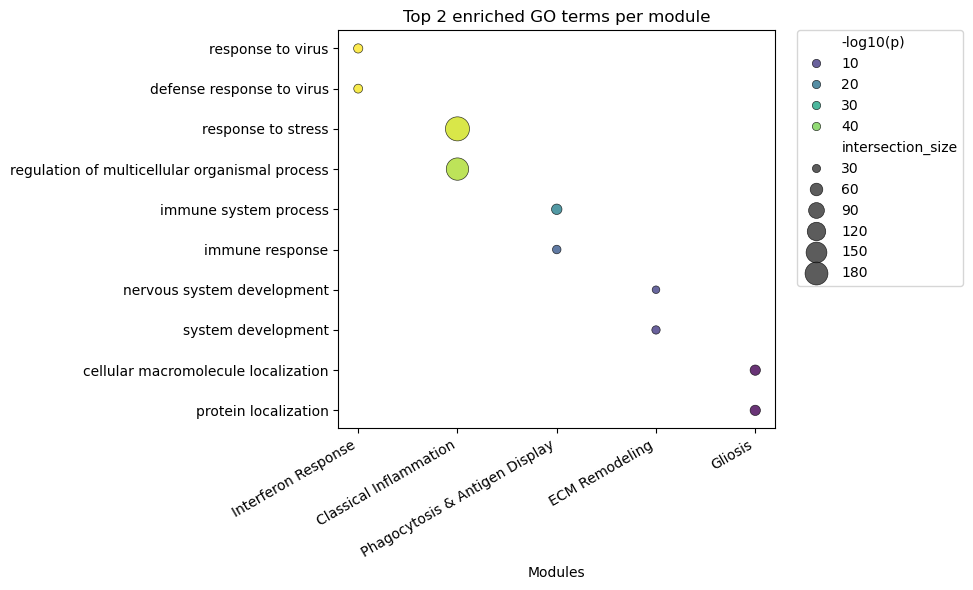

In [12]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("figures/go_dotplot_Microglia_CNA.svg")
plt.show()

### UMAP: ME expression

In [13]:
def plot_umap(data, x_col="x", y_col="y", color_col="turquoise", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots a UMAP visualization with a style similar to a minimal scatter plot.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the column to color.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        color_col (str): Column name for the color values.
        fig_width (float): Width of the figure.
        fig_height (float): Height of the figure.
        cmap (str): Colormap for the scatter plot.

    Returns:
        fig, ax: Matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    # Scatter plot with small marker size
    scatter = ax.scatter(
        data[x_col],
        data[y_col],
        s=0.5,
        c=data[color_col],
        cmap=cmap,
        marker='.',
        edgecolor='none'
    )

    # Set equal axis aspect ratio
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    # Add a colorbar
    fig.colorbar(scatter, ax=ax, orientation='vertical', label=color_col)
    return fig, ax

(<Figure size 400x400 with 2 Axes>, <Axes: >)

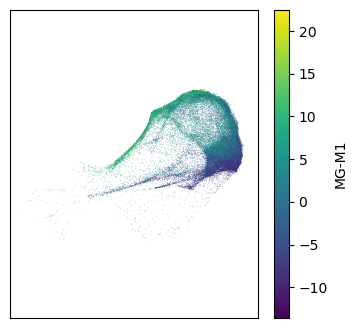

In [14]:
plot_umap(merged_df, color_col="MG-M1")

In [15]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

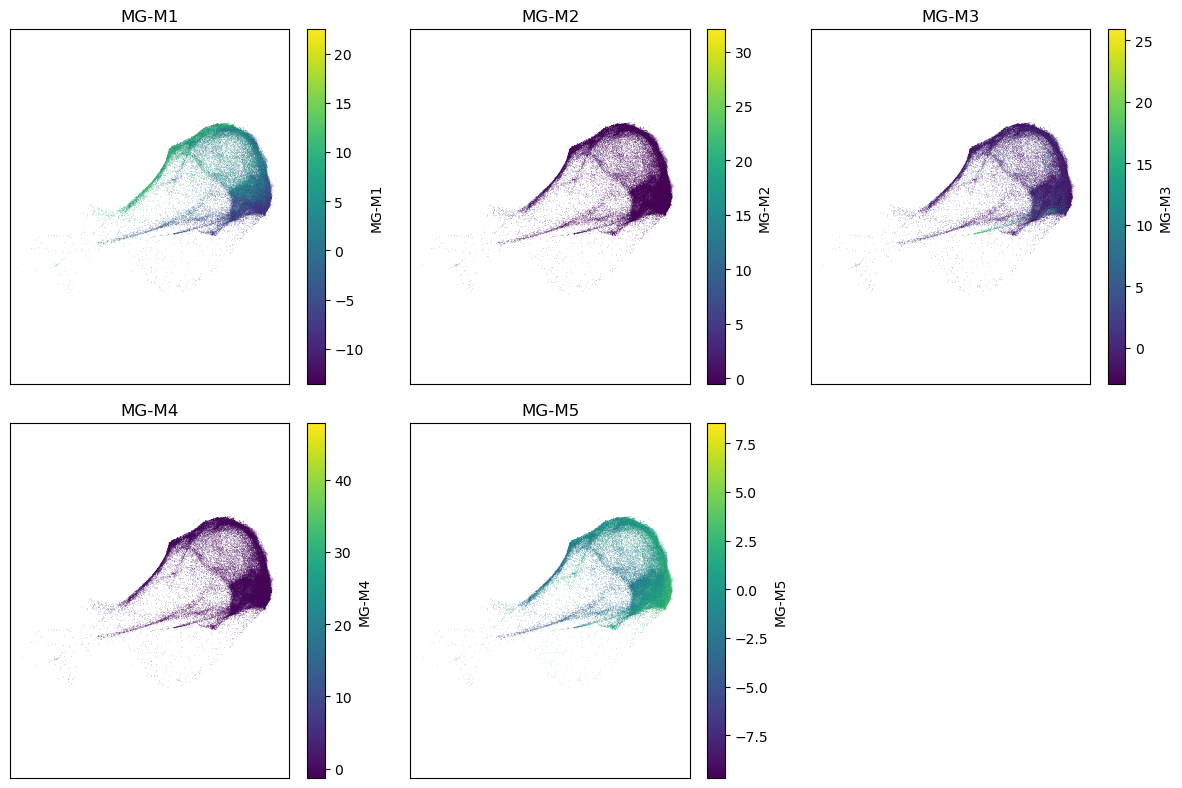

In [16]:
plot_multiple_umaps(merged_df, modules)

In [17]:
def plot_multiple_umaps_renamed(data, modules, module_names=None, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis", title=None):
    """
    Plots multiple UMAP visualizations for the specified modules with optional new names and a figure title.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        module_names (dict): Optional dictionary mapping old module names to new names for labeling.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.
        title (str): Title for the entire figure.

    Returns:
        None
    """
    n_cols = 3  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        # Use new name if provided, otherwise use the original module name
        title_text = module_names[module] if module_names and module in module_names else module
        ax.set_title(title_text)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=title_text)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Add a title to the entire figure if provided
    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the title
    plt.show()

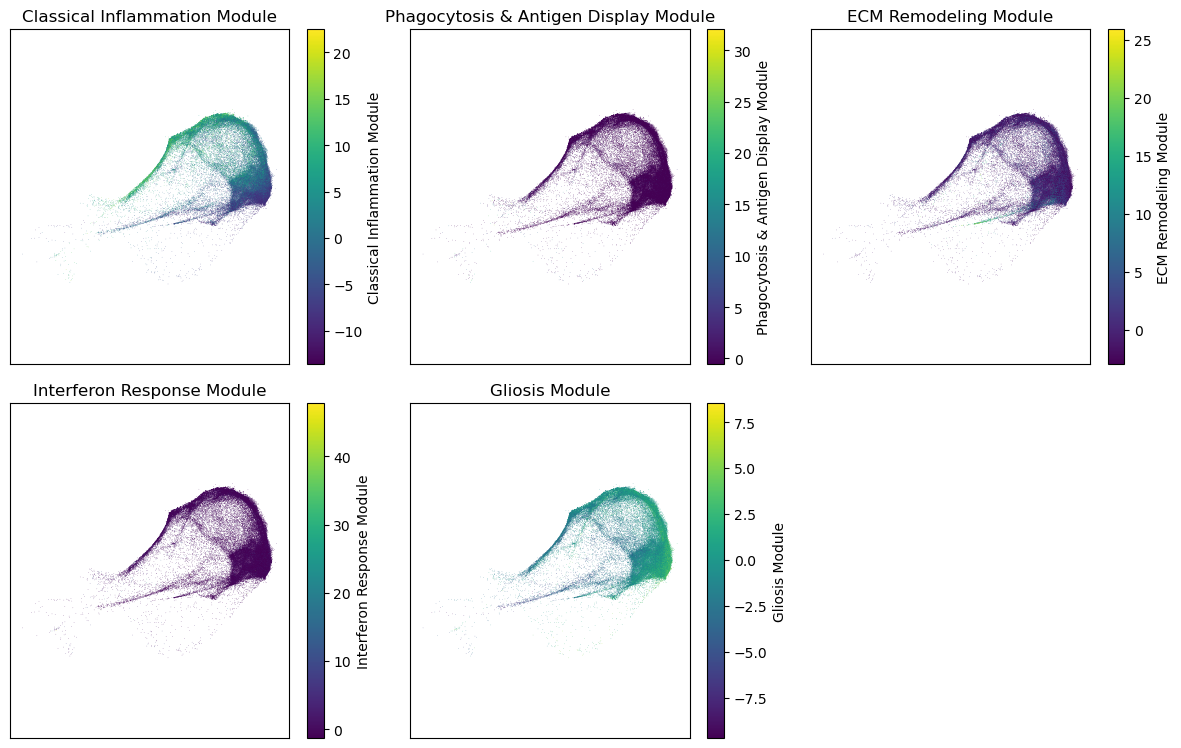

In [18]:
# output_file = "/home/momo/Pictures/ABCA/Isocortex_ME_UMAP.svg"
module_names = {
    "MG-M1": "Classical Inflammation Module",
    "MG-M2": "Phagocytosis & Antigen Display Module",
    "MG-M3": "ECM Remodeling Module",
    "MG-M4": "Interferon Response Module",
    "MG-M5": "Gliosis Module"
}
plot_multiple_umaps_renamed(merged_df, modules, module_names)

### Heatmap: ME across clusters

In [19]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-DEG-res0.50.h5ad"
adata_DEG = sc.read_h5ad(expr_path)
adata_DEG

AnnData object with n_obs × n_vars = 81472 × 2000
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch', 'leiden_res_0.50'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res_0.50', 'log1p', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [20]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[modules])
adata_vis.obs["clusters"] = adata_DEG.obs["leiden_res_0.50"]  # Add cell type labels

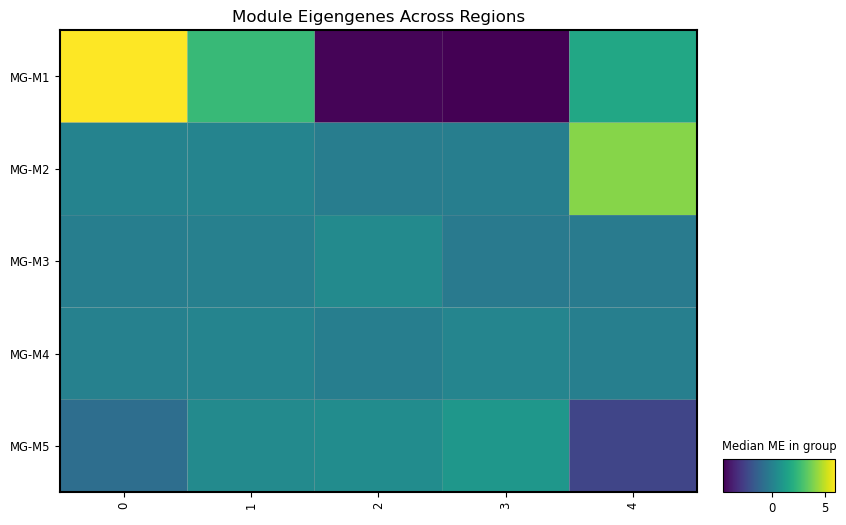

In [21]:
# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=modules,
    groupby="clusters",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Regions",
    colorbar_title="Median ME in group",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

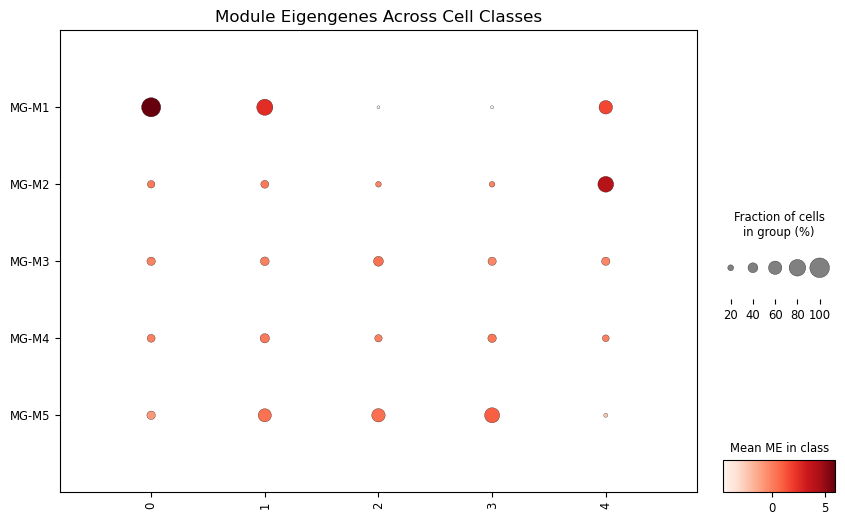

In [23]:
# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=modules,
    groupby="clusters",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    save = "ABCA_MG_modules.svg"
)

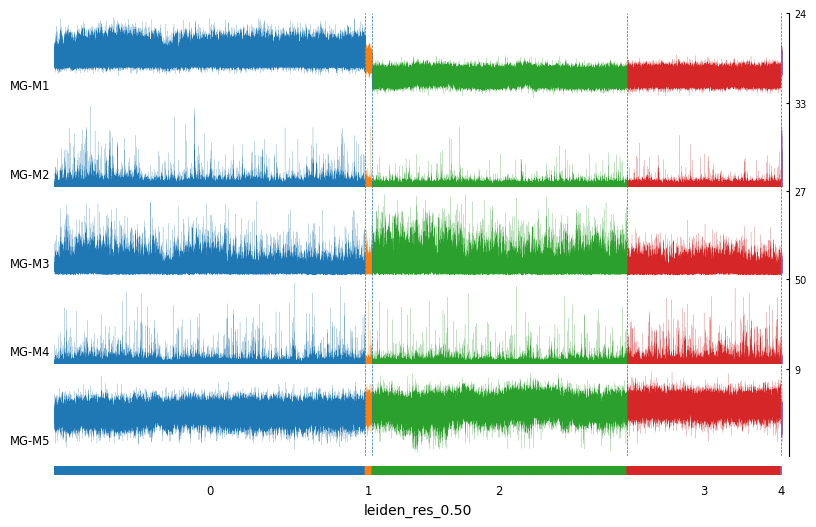

In [21]:
# Add all module eigengenes to AnnData and class labels
adata_tracks = sc.AnnData(merged_df[modules])

# Adding MEs to AnnData object
merged_df = pd.merge(adata_DEG.obs, MEs_df, left_index=True, right_index=True)

adata_tracks.obs["leiden_res_0.50"] = merged_df["leiden_res_0.50"].astype("category")  # Ensure categorical dtype

# # Setting the r-order of subclasses for plotting
# desired_order = ['001 CLA-EPd-CTX Car3 Glut', '004 L6 IT CTX Glut', '002 IT EP-CLA Glut',
# '005 L5 IT CTX Glut', '003 L5/6 IT TPE-ENT Glut', '006 L4/5 IT CTX Glut',
# '007 L2/3 IT CTX Glut', '022 L5 ET CTX Glut', '020 L2/3 IT RSP Glut', '021 L4 RSP-ACA Glut']
# adata_tracks.obs["subclass"] = adata_tracks.obs["subclass"].cat.reorder_categories(desired_order, ordered=True)

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=modules,
    groupby="leiden_res_0.50",
    figsize=(10, 6),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
    # save = "_glut_module_eigengenes.png"
)

### UMAP: hub gene kME

In [33]:
n_top_genes_per_module = 50  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    if module_name == "grey":
        continue  # Skip the grey module
    
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948
3,ENSMUSG00000053560,MG-M1,turquoise,0.731475,0.056730,0.067427,-0.052954,-0.023013,-0.355106
4,ENSMUSG00000021250,MG-M1,turquoise,0.667237,0.107338,0.060209,-0.019332,-0.024286,-0.335335


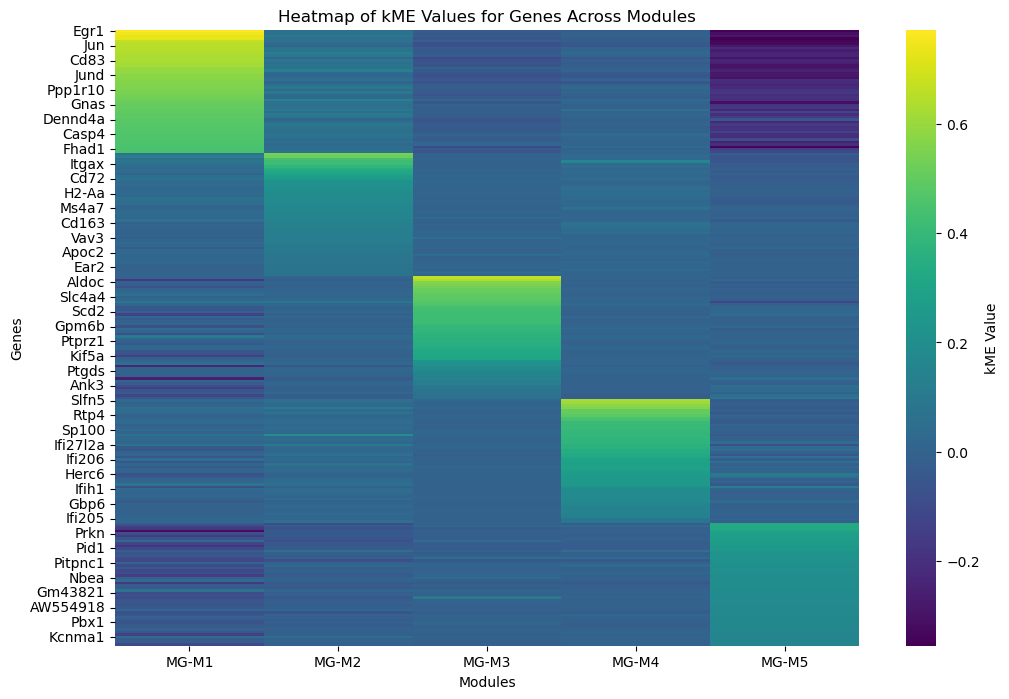

In [34]:
# Map gene IDs to gene symbols
gene_names_df = adata.var.copy()
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

### Specificity: Tau score

In [35]:
tau_scores = {}

for module in modules:
    tau_df = merged_df[["leiden_res_0.50", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('leiden_res_0.50', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for MG-M1 module: 0.370
Tau specificity score for MG-M2 module: 0.886
Tau specificity score for MG-M3 module: 0.175
Tau specificity score for MG-M4 module: 0.142
Tau specificity score for MG-M5 module: 0.149
